In [1]:
import numpy as np

In [2]:
import torch
t=torch.tensor([[2,2,4],[1,1,9]])
t=t.unsqueeze(2)
t=t.unsqueeze(3)
t=t.repeat((1,1,3,3))
t.shape

torch.Size([2, 3, 3, 3])

In [3]:
from numpy import linalg as LA
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

#all parents
P3=Pin+Pin2
P3[P3!=0]=1
print(P3)

E=W**2
needs=E@P3
needs=np.sqrt((needs))
print(needs)
row_l2_norm = LA.norm(W[:,[0,1,3]], axis=1)
print(row_l2_norm)
#needs[needs!=0]=1
#needs=pnormalize(needs)
#print(needs)
costs=Pout@C
#print(costs)
c1=1-Pout
costs[costs!=0]=1
#print(costs)
print(c1)
c2=Pout*(1e+10)
print(c2)
res1=needs*c1
res1=needs+c2
print(res1)
t=np.percentile(res1, 60)
print(t)
res1[res1<t]=0
res1[res1!=0]=1
print(res1)
mask=res1@np.transpose(P3)
mask[mask!=0]=1
print(mask)






[[1 0 1]
 [1 1 0]
 [0 1 1]
 [1 0 0]]
[[ 6.55743852  5.          5.        ]
 [10.          7.          9.21954446]
 [14.2126704  13.45362405 10.        ]
 [17.69180601 13.         12.        ]]
[ 6.55743852 10.         14.2126704  17.69180601]
[[1 0 1]
 [1 0 1]
 [1 1 0]
 [0 1 1]]
[[0.e+00 1.e+10 0.e+00]
 [0.e+00 1.e+10 0.e+00]
 [0.e+00 0.e+00 1.e+10]
 [1.e+10 0.e+00 0.e+00]]
[[6.55743852e+00 1.00000000e+10 5.00000000e+00]
 [1.00000000e+01 1.00000000e+10 9.21954446e+00]
 [1.42126704e+01 1.34536240e+01 1.00000000e+10]
 [1.00000000e+10 1.30000000e+01 1.20000000e+01]]
13.90905186096062
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 1.]
 [1. 0. 0.]]
[[0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [1. 1. 1. 1.]
 [1. 1. 0. 1.]]


In [33]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2))


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 7  0]
 [ 7  0]
 [ 0 19]
 [ 0 19]]
52


In [34]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=C
print(costs)

res2=needs@costs
print(res2)


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 0 19]
 [ 7  0]]
[[ 7 19]
 [ 0 19]
 [ 7 19]
 [ 7 19]]


In [27]:
import matplotlib.pyplot as plt
def ppp(f):
    # Create an array of x values
    x = np.linspace(0, 10, 1000)
    a=20
    # Calculate the PDF for each x value
    pdf = torch.tanh(torch.from_numpy(a*x)).numpy()

    # Plot the PDF
    plt.plot(x, pdf)
    plt.show()

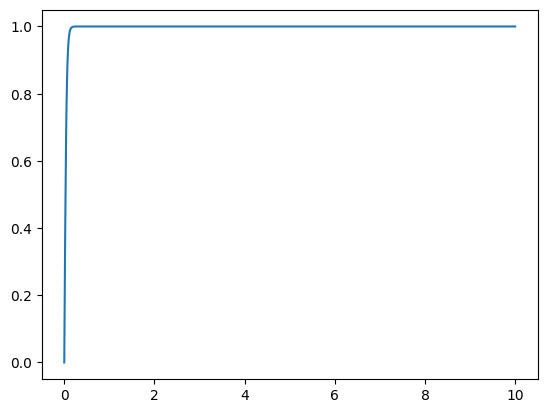

In [28]:
f=torch.tanh
ppp(f)

In [5]:
def softmax(x):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = np.exp((x - np.max(x))) # Subtracting np.max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

In [6]:
def pnormalize(x,p=2):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = x**p # Subtracting np.max(x) for numerical stability
    return e_x #/ e_x.sum(axis=0)

In [7]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[0.8,0.2],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0.2,0.8],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])


needs=E@Pin
print(needs)
#needs[needs!=0]=1
needs=pnormalize(needs)

print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2,axis=1))


[[2.6 1.4]
 [2.4 0.6]
 [1.8 1.2]
 [1.  1. ]]
[[6.76 1.96]
 [5.76 0.36]
 [3.24 1.44]
 [1.   1.  ]]
[[ 5.6  3.8]
 [ 5.6  3.8]
 [ 1.4 15.2]
 [ 1.4 15.2]]
[45.304 33.624 26.424 16.6  ]
